In [1]:
!pip install -U scikit-learn==1.5.2 scikeras==0.13.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 28.3 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
hdbscan 0.8.44 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.


In [2]:
import sklearn
import scikeras
import tensorflow as tf
import keras

print("scikit-learn:", sklearn.__version__)
print("SciKeras:", scikeras.__version__)
print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)

scikit-learn: 1.5.2
SciKeras: 0.13.0
TensorFlow: 2.20.0
Keras: 3.13.2


TASK 1: DATASET EXPLORATION
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training images: 60000 | shape: (28, 28)
Testing images : 10000 | shape: (28, 28)
Number of classes: 10
Saved: plots/02_class_distribution.png

Class distribution:
0    6000
1    6000
2    6000
3    6000
4    6000
5    6000
6    6000
7    6000
8    6000
9    6000
Name: count, dtype: int64


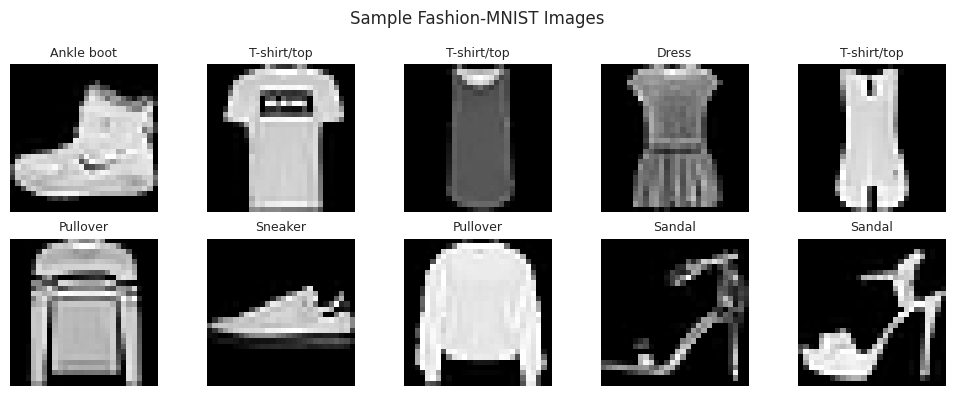

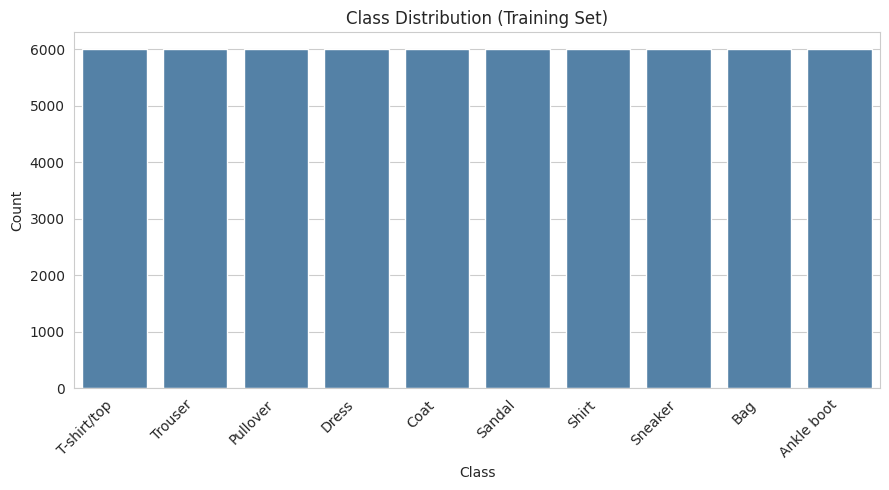

In [3]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)
from scikeras.wrappers import KerasClassifier

np.random.seed(42)
tf.random.set_seed(42)

sns.set_style("whitegrid")

CLASS_NAMES = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

# =========================================================
# TASK 1: DATASET EXPLORATION
# =========================================================
print("=" * 60)
print("TASK 1: DATASET EXPLORATION")
print("=" * 60)

(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = keras.datasets.fashion_mnist.load_data()

print(f"Training images: {X_train_raw.shape[0]} | shape: {X_train_raw.shape[1:]}")
print(f"Testing images : {X_test_raw.shape[0]} | shape: {X_test_raw.shape[1:]}")
print(f"Number of classes: {len(np.unique(y_train_raw))}")

# --- Sample images ---
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train_raw[i], cmap="gray")
    plt.title(CLASS_NAMES[y_train_raw[i]], fontsize=9)
    plt.axis("off")
plt.suptitle("Sample Fashion-MNIST Images")
plt.tight_layout()


# --- Class distribution ---
plt.figure(figsize=(9, 5))
class_counts = pd.Series(y_train_raw).value_counts().sort_index()
sns.barplot(x=[CLASS_NAMES[i] for i in class_counts.index], y=class_counts.values, color="steelblue")
plt.xticks(rotation=45, ha="right")
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class Distribution (Training Set)")
plt.tight_layout()

print("Saved: plots/02_class_distribution.png")
print("\nClass distribution:")
print(class_counts)


In [4]:

# =========================================================
# TASK 2: DATA PREPROCESSING
# =========================================================
print("\n" + "=" * 60)
print("TASK 2: DATA PREPROCESSING")
print("=" * 60)

print(f"Shape before flattening: {X_train_raw.shape}")

# Flatten 28x28 -> 784
X_train = X_train_raw.reshape(X_train_raw.shape[0], 784).astype("float32")
X_test = X_test_raw.reshape(X_test_raw.shape[0], 784).astype("float32")

# Normalize pixels to [0, 1]
X_train /= 255.0
X_test /= 255.0

print(f"Shape after flattening: {X_train.shape}")
print(f"Pixel value range after normalization: [{X_train.min():.2f}, {X_train.max():.2f}]")

# One-hot encode labels
y_train = to_categorical(y_train_raw, num_classes=10)
y_test = to_categorical(y_test_raw, num_classes=10)

print(f"Label shape before one-hot: {y_train_raw.shape}")
print(f"Label shape after one-hot : {y_train.shape}")


TASK 2: DATA PREPROCESSING
Shape before flattening: (60000, 28, 28)
Shape after flattening: (60000, 784)
Pixel value range after normalization: [0.00, 1.00]
Label shape before one-hot: (60000,)
Label shape after one-hot : (60000, 10)


In [5]:

# =========================================================
# TASK 3: MODEL CONSTRUCTION
# =========================================================
print("\n" + "=" * 60)
print("TASK 3: MODEL CONSTRUCTION (Baseline)")
print("=" * 60)


def build_model(hidden_layers=2, hidden_neurons=128, learning_rate=0.001,
                 optimizer_name="adam", activation="relu", dropout_rate=0.0):
    """Builds an MLP with a configurable architecture (used for both the
    baseline model and the hyperparameter search)."""
    model = keras.Sequential()
    model.add(layers.Input(shape=(784,)))

    neurons = hidden_neurons
    for i in range(hidden_layers):
        model.add(layers.Dense(neurons, activation=activation))
        if dropout_rate > 0:
            model.add(layers.Dropout(dropout_rate))
        neurons = max(neurons // 2, 16)  # shrink each subsequent layer, like 128 -> 64

    model.add(layers.Dense(10, activation="softmax"))

    if optimizer_name == "adam":
        opt = keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer_name == "sgd":
        opt = keras.optimizers.SGD(learning_rate=learning_rate)
    elif optimizer_name == "rmsprop":
        opt = keras.optimizers.RMSprop(learning_rate=learning_rate)
    else:
        raise ValueError(f"Unknown optimizer: {optimizer_name}")

    model.compile(optimizer=opt, loss="categorical_crossentropy", metrics=["accuracy"])
    return model


# Baseline model: 784 -> Dense(128, ReLU) -> Dense(64, ReLU) -> Dense(10, Softmax)
baseline_model = build_model(hidden_layers=2, hidden_neurons=128, learning_rate=0.001,
                              optimizer_name="adam", activation="relu", dropout_rate=0.0)
baseline_model.summary()


TASK 3: MODEL CONSTRUCTION (Baseline)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)


TASK 4: MODEL TRAINING (Baseline)
Epoch 1/20
1688/1688 - 7s - 4ms/step - accuracy: 0.8184 - loss: 0.5082 - val_accuracy: 0.8510 - val_loss: 0.4018
Epoch 2/20
1688/1688 - 7s - 4ms/step - accuracy: 0.8637 - loss: 0.3760 - val_accuracy: 0.8637 - val_loss: 0.3627
Epoch 3/20
1688/1688 - 6s - 3ms/step - accuracy: 0.8756 - loss: 0.3368 - val_accuracy: 0.8658 - val_loss: 0.3477
Epoch 4/20
1688/1688 - 7s - 4ms/step - accuracy: 0.8865 - loss: 0.3112 - val_accuracy: 0.8707 - val_loss: 0.3481
Epoch 5/20
1688/1688 - 6s - 3ms/step - accuracy: 0.8913 - loss: 0.2925 - val_accuracy: 0.8717 - val_loss: 0.3484
Epoch 6/20
1688/1688 - 7s - 4ms/step - accuracy: 0.8982 - loss: 0.2779 - val_accuracy: 0.8738 - val_loss: 0.3581
Epoch 7/20
1688/1688 - 6s - 3ms/step - accuracy: 0.9028 - loss: 0.2625 - val_accuracy: 0.8710 - val_loss: 0.3640
Epoch 8/20
1688/1688 - 7s - 4ms/step - accuracy: 0.9064 - loss: 0.2508 - val_accuracy: 0.8747 - val_loss: 0.3569
Epoch 9/20
1688/1688 - 6s - 3ms/step - accuracy: 0.9105 - los

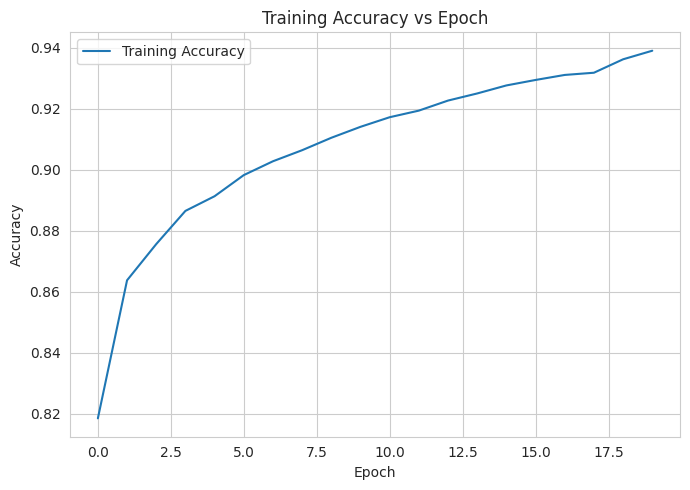

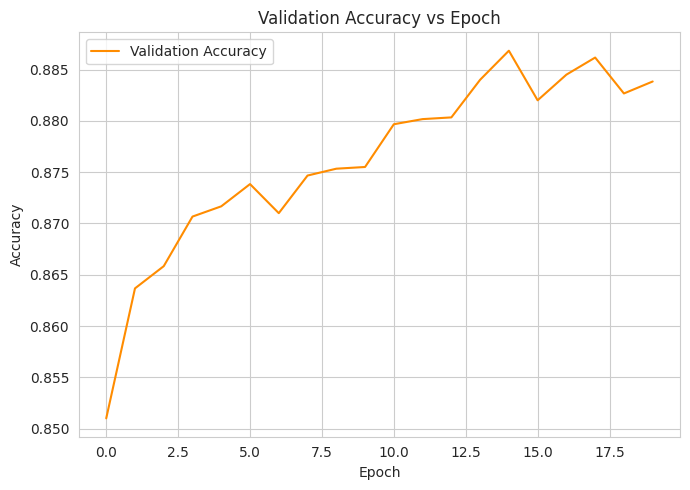

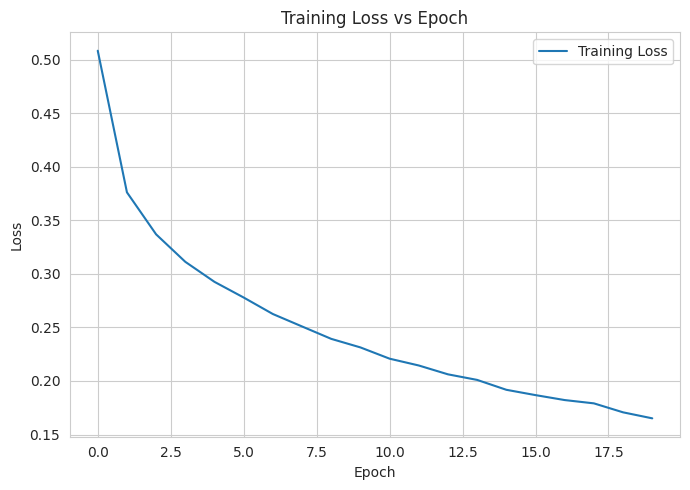

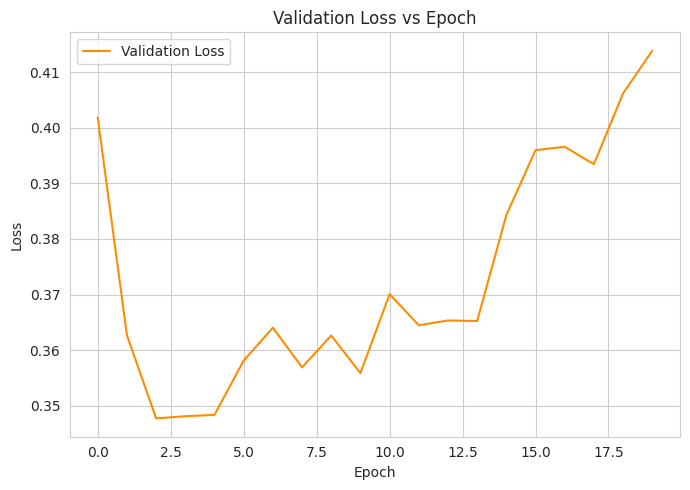

In [6]:

# =========================================================
# TASK 4: MODEL TRAINING (Baseline)
# =========================================================
print("\n" + "=" * 60)
print("TASK 4: MODEL TRAINING (Baseline)")
print("=" * 60)

start_time = time.time()
history = baseline_model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=32,
    verbose=2
)
baseline_train_time = time.time() - start_time
print(f"Baseline training time: {baseline_train_time:.2f} seconds")

# --- Training/Validation Accuracy and Loss plots ---
plt.figure(figsize=(7, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy vs Epoch")
plt.legend()
plt.tight_layout()

plt.figure(figsize=(7, 5))
plt.plot(history.history["val_accuracy"], label="Validation Accuracy", color="darkorange")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy vs Epoch")
plt.legend()
plt.tight_layout()


plt.figure(figsize=(7, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss vs Epoch")
plt.legend()
plt.tight_layout()

plt.figure(figsize=(7, 5))
plt.plot(history.history["val_loss"], label="Validation Loss", color="darkorange")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Validation Loss vs Epoch")
plt.legend()
plt.tight_layout()



TASK 5: MODEL EVALUATION (Baseline)
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Baseline Accuracy : 0.8820
Baseline Precision: 0.8837
Baseline Recall   : 0.8820
Baseline F1-score : 0.8799

Classification Report (Baseline):
              precision    recall  f1-score   support

 T-shirt/top       0.76      0.90      0.82      1000
     Trouser       0.98      0.97      0.98      1000
    Pullover       0.79      0.80      0.79      1000
       Dress       0.86      0.91      0.89      1000
        Coat       0.77      0.84      0.80      1000
      Sandal       0.97      0.96      0.97      1000
       Shirt       0.80      0.56      0.66      1000
     Sneaker       0.93      0.97      0.95      1000
         Bag       0.99      0.96      0.97      1000
  Ankle boot       0.98      0.95      0.96      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



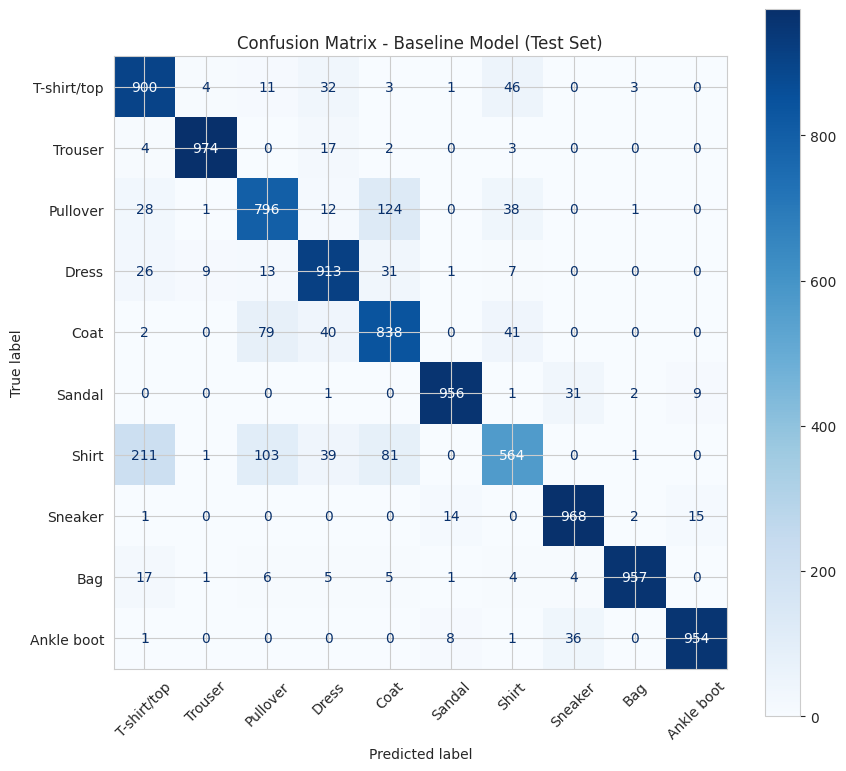

In [7]:

# =========================================================
# TASK 5: MODEL EVALUATION (Baseline)
# =========================================================
print("\n" + "=" * 60)
print("TASK 5: MODEL EVALUATION (Baseline)")
print("=" * 60)

y_pred_probs = baseline_model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

baseline_acc = accuracy_score(y_true, y_pred)
baseline_prec = precision_score(y_true, y_pred, average="macro")
baseline_rec = recall_score(y_true, y_pred, average="macro")
baseline_f1 = f1_score(y_true, y_pred, average="macro")

print(f"Baseline Accuracy : {baseline_acc:.4f}")
print(f"Baseline Precision: {baseline_prec:.4f}")
print(f"Baseline Recall   : {baseline_rec:.4f}")
print(f"Baseline F1-score : {baseline_f1:.4f}")

print("\nClassification Report (Baseline):")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
fig, ax = plt.subplots(figsize=(9, 8))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=True)
plt.title("Confusion Matrix - Baseline Model (Test Set)")
plt.tight_layout()



HYPERPARAMETER OPTIMIZATION (RandomizedSearchCV)
Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END activation=tanh, batch_size=128, dropout_rate=0.2, epochs=20, hidden_layers=1, hidden_neurons=256, learning_rate=0.001, optimizer_name=adam; total time=   6.6s
[CV] END activation=tanh, batch_size=128, dropout_rate=0.2, epochs=20, hidden_layers=1, hidden_neurons=256, learning_rate=0.001, optimizer_name=adam; total time=   7.7s
[CV] END activation=tanh, batch_size=128, dropout_rate=0.2, epochs=20, hidden_layers=1, hidden_neurons=256, learning_rate=0.001, optimizer_name=adam; total time=   6.3s
[CV] END activation=tanh, batch_size=128, dropout_rate=0.2, epochs=20, hidden_layers=1, hidden_neurons=256, learning_rate=0.001, optimizer_name=adam; total time=   7.7s
[CV] END activation=tanh, batch_size=128, dropout_rate=0.2, epochs=20, hidden_layers=1, hidden_neurons=256, learning_rate=0.001, optimizer_name=adam; total time=   6.4s
[CV] END activation=relu, batch_size=16, dr

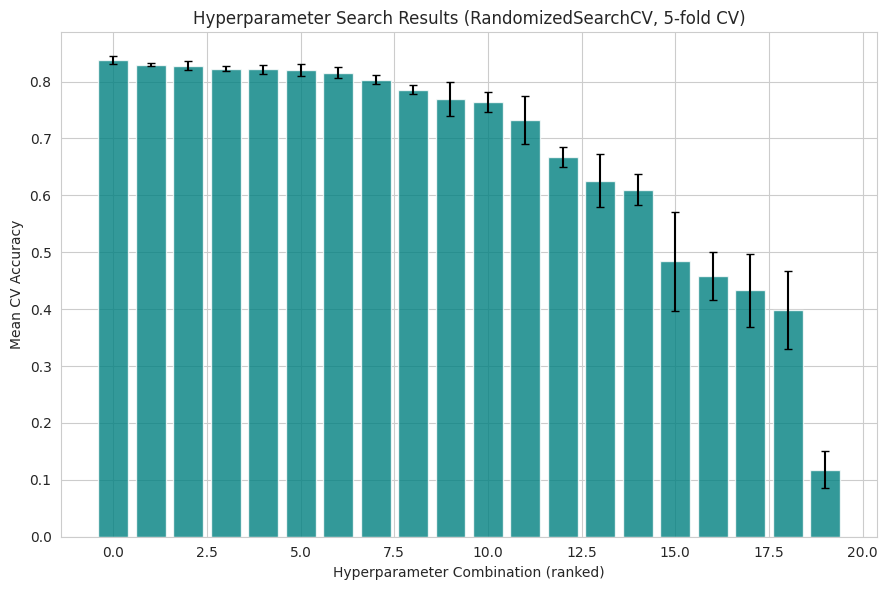

In [8]:




# =========================================================
# TASK 7: HYPERPARAMETER OPTIMIZATION (RandomizedSearchCV + SciKeras)
# =========================================================
print("\n" + "=" * 60)
print("HYPERPARAMETER OPTIMIZATION (RandomizedSearchCV)")
print("=" * 60)

# SciKeras-compatible builder: hyperparameters are passed as kwargs
def build_model_for_search(hidden_layers=2, hidden_neurons=128, learning_rate=0.001,
                            optimizer_name="adam", activation="relu", dropout_rate=0.0):
    return build_model(hidden_layers=hidden_layers, hidden_neurons=hidden_neurons,
                        learning_rate=learning_rate, optimizer_name=optimizer_name,
                        activation=activation, dropout_rate=dropout_rate)


clf = KerasClassifier(
    model=build_model_for_search,
    hidden_layers=2,
    hidden_neurons=128,
    learning_rate=0.001,
    optimizer_name="adam",
    activation="relu",
    dropout_rate=0.0,
    epochs=10,
    batch_size=32,
    verbose=0,
)

# Search space (Section 7 of the manual)
param_distributions = {
    "hidden_layers": [1, 2, 3],
    "hidden_neurons": [32, 64, 128, 256],
    "learning_rate": [0.1, 0.01, 0.001],
    "batch_size": [16, 32, 64, 128],
    "epochs": [10, 20, 30],
    "optimizer_name": ["sgd", "adam", "rmsprop"],
    "activation": ["relu", "tanh", "sigmoid"],
    "dropout_rate": [0.0, 0.2, 0.5],
}

# NOTE: Fashion-MNIST has 60,000 training images; running RandomizedSearchCV
# with 5-fold CV on the full set is very expensive. A stratified subsample
# is used here to keep search time reasonable, which is standard practice
# for hyperparameter search before final retraining on the full dataset.
SEARCH_SAMPLE_SIZE = 6000
rng = np.random.RandomState(42)
search_idx = rng.choice(X_train.shape[0], size=SEARCH_SAMPLE_SIZE, replace=False)
X_search, y_search = X_train[search_idx], y_train[search_idx]

random_search = RandomizedSearchCV(
    estimator=clf,
    param_distributions=param_distributions,
    n_iter=20,
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=1,
)

search_start = time.time()
random_search.fit(X_search, y_search)
search_time = time.time() - search_start
print(f"\nHyperparameter search time: {search_time:.2f} seconds")

print("\nBest hyperparameters found:")
for k, v in random_search.best_params_.items():
    print(f"  {k}: {v}")
print(f"Best cross-validation accuracy: {random_search.best_score_:.4f}")

# --- Hyperparameter search results plot ---
results_df = pd.DataFrame(random_search.cv_results_)
results_df_sorted = results_df.sort_values("mean_test_score", ascending=False).reset_index(drop=True)

plt.figure(figsize=(9, 6))
plt.bar(range(len(results_df_sorted)), results_df_sorted["mean_test_score"],
        yerr=results_df_sorted["std_test_score"], color="teal", alpha=0.8, capsize=3)
plt.xlabel("Hyperparameter Combination (ranked)")
plt.ylabel("Mean CV Accuracy")
plt.title("Hyperparameter Search Results (RandomizedSearchCV, 5-fold CV)")
plt.tight_layout()


In [9]:


# =========================================================
# TASKS 5-6 (Section 7): RETRAIN AND EVALUATE OPTIMIZED MODEL
# =========================================================
print("\n" + "=" * 60)
print("RETRAINING OPTIMIZED MODEL ON FULL TRAINING SET")
print("=" * 60)

best_params = random_search.best_params_

optimized_model = build_model(
    hidden_layers=best_params["hidden_layers"],
    hidden_neurons=best_params["hidden_neurons"],
    learning_rate=best_params["learning_rate"],
    optimizer_name=best_params["optimizer_name"],
    activation=best_params["activation"],
    dropout_rate=best_params["dropout_rate"],
)

opt_start = time.time()
opt_history = optimized_model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=best_params["epochs"],
    batch_size=best_params["batch_size"],
    verbose=2
)
optimized_train_time = time.time() - opt_start
print(f"Optimized model training time: {optimized_train_time:.2f} seconds")

y_pred_opt_probs = optimized_model.predict(X_test)
y_pred_opt = np.argmax(y_pred_opt_probs, axis=1)

optimized_acc = accuracy_score(y_true, y_pred_opt)
optimized_prec = precision_score(y_true, y_pred_opt, average="macro")
optimized_rec = recall_score(y_true, y_pred_opt, average="macro")
optimized_f1 = f1_score(y_true, y_pred_opt, average="macro")

print(f"Optimized Accuracy : {optimized_acc:.4f}")
print(f"Optimized Precision: {optimized_prec:.4f}")
print(f"Optimized Recall   : {optimized_rec:.4f}")
print(f"Optimized F1-score : {optimized_f1:.4f}")



RETRAINING OPTIMIZED MODEL ON FULL TRAINING SET
Epoch 1/20
422/422 - 4s - 9ms/step - accuracy: 0.8013 - loss: 0.5575 - val_accuracy: 0.8440 - val_loss: 0.4351
Epoch 2/20
422/422 - 3s - 6ms/step - accuracy: 0.8466 - loss: 0.4290 - val_accuracy: 0.8537 - val_loss: 0.3988
Epoch 3/20
422/422 - 3s - 8ms/step - accuracy: 0.8571 - loss: 0.3967 - val_accuracy: 0.8612 - val_loss: 0.3776
Epoch 4/20
422/422 - 3s - 7ms/step - accuracy: 0.8648 - loss: 0.3751 - val_accuracy: 0.8625 - val_loss: 0.3727
Epoch 5/20
422/422 - 3s - 6ms/step - accuracy: 0.8710 - loss: 0.3565 - val_accuracy: 0.8685 - val_loss: 0.3570
Epoch 6/20
422/422 - 3s - 6ms/step - accuracy: 0.8729 - loss: 0.3469 - val_accuracy: 0.8717 - val_loss: 0.3429
Epoch 7/20
422/422 - 6s - 15ms/step - accuracy: 0.8779 - loss: 0.3333 - val_accuracy: 0.8755 - val_loss: 0.3369
Epoch 8/20
422/422 - 3s - 6ms/step - accuracy: 0.8811 - loss: 0.3225 - val_accuracy: 0.8797 - val_loss: 0.3294
Epoch 9/20
422/422 - 3s - 6ms/step - accuracy: 0.8834 - loss: 


Performance Comparison Table:

Training Time Comparison:


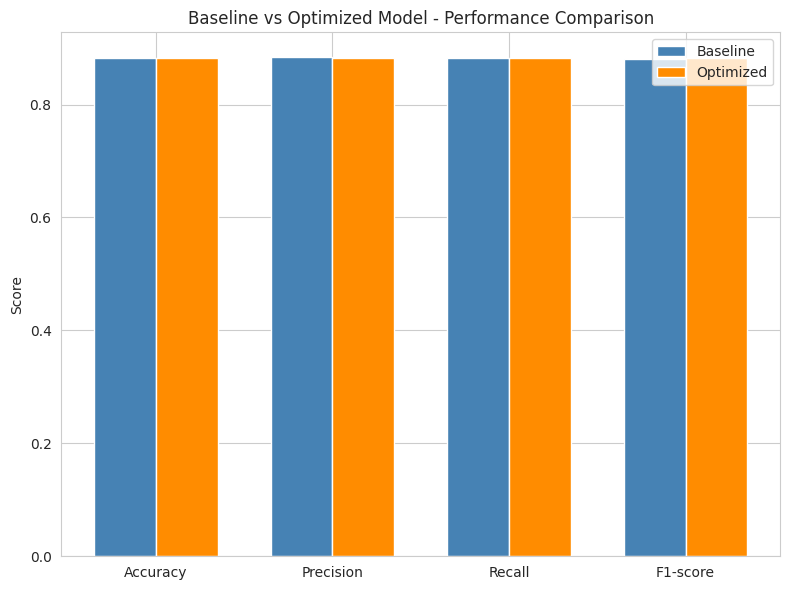

In [12]:

# =========================================================
# BEST MODEL ACCURACY COMPARISON PLOT
# =========================================================
comparison_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Baseline": [baseline_acc, baseline_prec, baseline_rec, baseline_f1],
    "Optimized": [optimized_acc, optimized_prec, optimized_rec, optimized_f1],
})

x = np.arange(len(comparison_df))
width = 0.35
plt.figure(figsize=(8, 6))
plt.bar(x - width / 2, comparison_df["Baseline"], width, label="Baseline", color="steelblue")
plt.bar(x + width / 2, comparison_df["Optimized"], width, label="Optimized", color="darkorange")
plt.xticks(x, comparison_df["Metric"])
plt.ylabel("Score")
plt.title("Baseline vs Optimized Model - Performance Comparison")
plt.legend()
plt.tight_layout()


print("\nPerformance Comparison Table:")

training_time_df = pd.DataFrame({
    "Model": ["Baseline", "Optimized"],
    "Training Time (s)": [round(baseline_train_time, 2), round(optimized_train_time, 2)]
})
print("\nTraining Time Comparison:")


In [13]:


# =========================================================
# RESULTS SUMMARY
# =========================================================
print("\n" + "=" * 60)
print("RESULTS SUMMARY")
print("=" * 60)
summary = pd.DataFrame({
    "Parameter": ["Hidden Layers", "Hidden Neurons", "Learning Rate", "Batch Size",
                  "Optimizer", "Activation Function", "Epochs", "Dropout",
                  "Cross-validation Accuracy", "Testing Accuracy"],
    "Value": [best_params["hidden_layers"], best_params["hidden_neurons"],
              best_params["learning_rate"], best_params["batch_size"],
              best_params["optimizer_name"], best_params["activation"],
              best_params["epochs"], best_params["dropout_rate"],
              round(random_search.best_score_, 4), round(optimized_acc, 4)]
})
print(summary.to_string(index=False))



RESULTS SUMMARY
                Parameter   Value
            Hidden Layers       1
           Hidden Neurons     256
            Learning Rate   0.001
               Batch Size     128
                Optimizer    adam
      Activation Function    tanh
                   Epochs      20
                  Dropout     0.2
Cross-validation Accuracy  0.8375
         Testing Accuracy  0.8825
